# K07_02 - k-NN auf MNIST: Hyperparameter und Laufzeit

## Lernziele
- MNIST-Daten fuer k-NN vorbereiten
- Bilder in Vektoren umwandeln (**Flattening**)
- Vorverarbeitung und Modell sauber in einer **Pipeline** kapseln
- eine Hyperparameter-Suche mit `GridSearchCV` durchfuehren
- Accuracy, Laufzeit und Rechenkosten gemeinsam betrachten
- Fehlklassifikationen visuell und quantitativ analysieren
- den **Fluch der Dimensionalitaet** als praktische Grenze von k-NN verstehen

## Didaktischer Fokus

Dieses Notebook ist bewusst **umfangreicher und anspruchsvoller**.

Es ist kein Mini-Beispiel, sondern eine **Projektaufgabe**:
- Datenvorbereitung
- Pipeline-Aufbau
- Hyperparameter-Suche
- Evaluation
- Laufzeitbewertung
- Fehleranalyse

**Wichtiger Hinweis:**  
k-NN auf vollem MNIST kann sehr rechenintensiv sein.  
Fuer erste Experimente ist daher Subsampling sinnvoll.


## 1. Bibliotheken importieren


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print('Alle Bibliotheken erfolgreich geladen')


Alle Bibliotheken erfolgreich geladen


## 2. MNIST laden


In [2]:
import tensorflow as tf

(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Trainings- und Testdaten zusammenfuehren fuer konsistentes Subsampling
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

# Flattening: 28x28 Bild -> 784-dimensionaler Vektor
# k-NN erwartet Vektoren, keine 2D-Bilder
X = X.reshape(X.shape[0], -1)

print(f'Shape von X: {X.shape}  ->  {X.shape[0]} Bilder, je {X.shape[1]} Pixel-Features')
print(f'Shape von y: {y.shape}')
print(f'Pixelwerte: min={X.min()}, max={X.max()}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shape von X: (70000, 784)  ->  70000 Bilder, je 784 Pixel-Features
Shape von y: (70000,)
Pixelwerte: min=0, max=255


## 3. Daten verkleinern fuer erste Experimente

k-NN speichert alle Trainingsdaten und berechnet bei jeder Vorhersage  
Abstaende zu **allen** Trainingspunkten. Bei 70.000 Bildern x 784 Dimensionen  
wird das sehr teuer. Wir starten daher mit einem Subset.


In [3]:
# stratify=y sorgt dafuer, dass alle 10 Ziffern gleichmaessig vertreten sind
X_small, _, y_small, _ = train_test_split(
    X, y, train_size=12000, stratify=y, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=42
)

print(f'Trainingsdaten: {X_train.shape}')
print(f'Testdaten:      {X_test.shape}')


Trainingsdaten: (9600, 784)
Testdaten:      (2400, 784)


## 4. Pipeline aufbauen

**Warum eine Pipeline und kein manueller Scaler?**

Eine Pipeline kapselt Vorverarbeitung und Modell in einem Objekt. Das hat zwei entscheidende Vorteile:

1. **Kein Data Leakage:** `fit_transform()` wird nur auf Trainingsdaten angewendet.  
   Die Pipeline stellt das automatisch sicher.
2. **Saubere Integration in GridSearchCV:** Die Hyperparameter-Suche verwendet intern  
   selbst Cross-Validation. Ohne Pipeline wuerde der Scaler die Validierungsdaten 'sehen',  
   was das Ergebnis verfaelscht.

```
Manuell (fehleranfaellig):
   scaler.fit_transform(X_train)  ->  scaler.transform(X_test)
   knn.fit(X_train_scaled)        ->  knn.predict(X_test_scaled)

Mit Pipeline (sicher und empfohlen):
   pipeline.fit(X_train)          ->  pipeline.predict(X_test)
```

**Warum `MinMaxScaler` (nicht `StandardScaler`)?**  
Pixelwerte liegen immer zwischen 0 und 255 - ein bekannter, fester Wertebereich.  
`MinMaxScaler` skaliert auf [0, 1], was fuer Bilddaten intuitiv und ueblich ist.  
`StandardScaler` waere hier ebenfalls moeglich und liefert vergleichbare Ergebnisse.


In [4]:
# Pipeline: Skalierung -> k-NN
# Hyperparameter des k-NN werden mit dem Praefix 'knn__' angesprochen
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn',    KNeighborsClassifier())
])

print('Pipeline erstellt:')
print(pipeline)


Pipeline erstellt:
Pipeline(steps=[('scaler', MinMaxScaler()), ('knn', KNeighborsClassifier())])


## 5. Basismodell

Wir starten mit einem einfachen k-NN (k=3, uniform) als Referenzpunkt.


In [5]:
pipeline.set_params(knn__n_neighbors=3, knn__weights='uniform')

start = time.time()
pipeline.fit(X_train, y_train)
y_pred_base = pipeline.predict(X_test)
runtime_base = time.time() - start

acc_base = accuracy_score(y_test, y_pred_base)

print(f'Baseline-Accuracy: {acc_base:.4f}')
print(f'Laufzeit:          {runtime_base:.1f} Sekunden')


Baseline-Accuracy: 0.9487
Laufzeit:          1.8 Sekunden


## 6. Hyperparameter-Suche mit GridSearchCV

Wir suchen systematisch ueber:
- `n_neighbors`: wie viele Nachbarn zaehlen?
- `weights`: alle gleich oder naechste staerker gewichten?

**Hinweis zu `n_jobs=-1`:**  
Auf Google Colab stehen mehrere CPU-Kerne zur Verfuegung.  
`n_jobs=-1` nutzt alle davon gleichzeitig - das reduziert die Laufzeit erheblich.


In [6]:
# Parameterbezeichnung: 'knn__' + Parametername (wegen Pipeline)
param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9],
    'knn__weights':     ['uniform', 'distance']
}

grid = GridSearchCV(
    pipeline,          # Pipeline statt rohem Modell!
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,         # alle verfuegbaren CPU-Kerne nutzen
    verbose=1
)

start = time.time()
grid.fit(X_train, y_train)
runtime_grid = time.time() - start

print(f'\nBeste Parameter:     {grid.best_params_}')
print(f'Beste CV-Accuracy:   {grid.best_score_:.4f}')
print(f'Laufzeit GridSearch: {runtime_grid:.1f} Sekunden')


Fitting 3 folds for each of 10 candidates, totalling 30 fits

Beste Parameter:     {'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Beste CV-Accuracy:   0.9443
Laufzeit GridSearch: 42.3 Sekunden


## 7. Bestes Modell auf Testdaten evaluieren


In [7]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

print(f'Test-Accuracy Basismodell:       {acc_base:.4f}')
print(f'Test-Accuracy bestes GridSearch: {acc_best:.4f}')
print(f'Verbesserung:                    +{(acc_best - acc_base):.4f}')


Test-Accuracy Basismodell:       0.9487
Test-Accuracy bestes GridSearch: 0.9521
Verbesserung:                    +0.0033


## 8. Laufzeit visualisieren

Laufzeit ist ein zentrales Thema bei k-NN.  
Der Vergleich macht deutlich: GridSearch verbessert das Modell oft nur moderat,  
kostet aber ein Vielfaches an Rechenzeit.


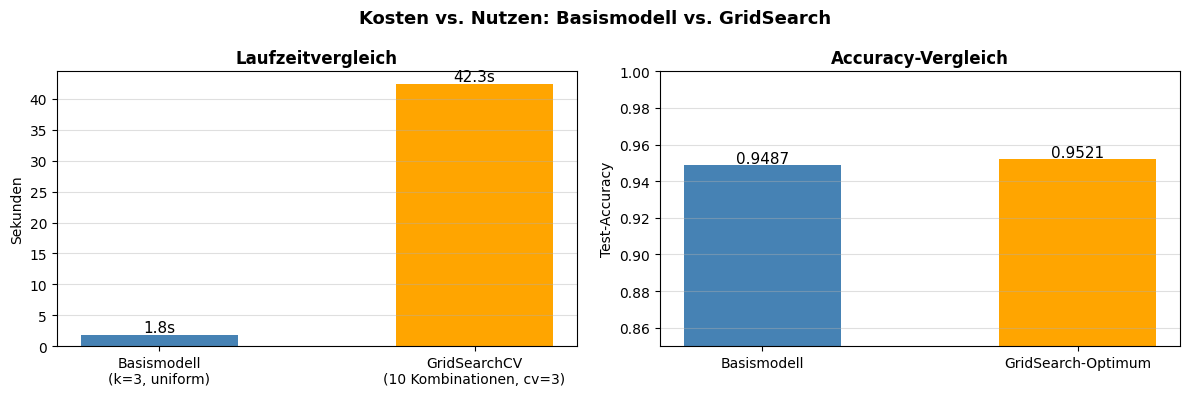


Fazit: GridSearch ist 23x langsamer, verbessert die Accuracy aber nur um 0.33 Prozentpunkte.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels  = ['Basismodell\n(k=3, uniform)', 'GridSearchCV\n(10 Kombinationen, cv=3)']
times   = [runtime_base, runtime_grid]
colors  = ['steelblue', 'orange']

bars = axes[0].bar(labels, times, color=colors, width=0.5)
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{t:.1f}s', ha='center', fontsize=11)
axes[0].set_ylabel('Sekunden')
axes[0].set_title('Laufzeitvergleich', fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)

accs    = [acc_base, acc_best]
labels2 = ['Basismodell', 'GridSearch-Optimum']
bars2 = axes[1].bar(labels2, accs, color=colors, width=0.5)
for bar, a in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{a:.4f}', ha='center', fontsize=11)
axes[1].set_ylabel('Test-Accuracy')
axes[1].set_ylim(0.85, 1.0)
axes[1].set_title('Accuracy-Vergleich', fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Kosten vs. Nutzen: Basismodell vs. GridSearch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nFazit: GridSearch ist {runtime_grid/runtime_base:.0f}x langsamer,',
      f'verbessert die Accuracy aber nur um {(acc_best - acc_base)*100:.2f} Prozentpunkte.')


## 9. Konfusionsmatrix


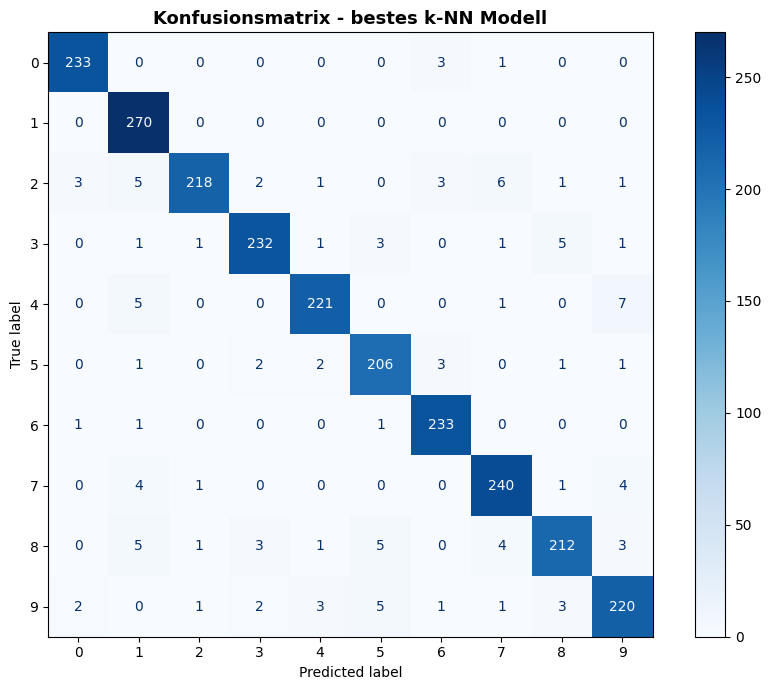

In [9]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Konfusionsmatrix - bestes k-NN Modell', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Fehleranalyse: Falsch klassifizierte Bilder

Die Konfusionsmatrix zeigt **wo** Fehler passieren.  
Diese Zelle zeigt **wie** die falsch klassifizierten Bilder aussehen -  
und warum das Modell sie verwechselt hat.


Anzahl Fehler: 115 von 2400 Testbildern
Fehlerrate:    4.79%


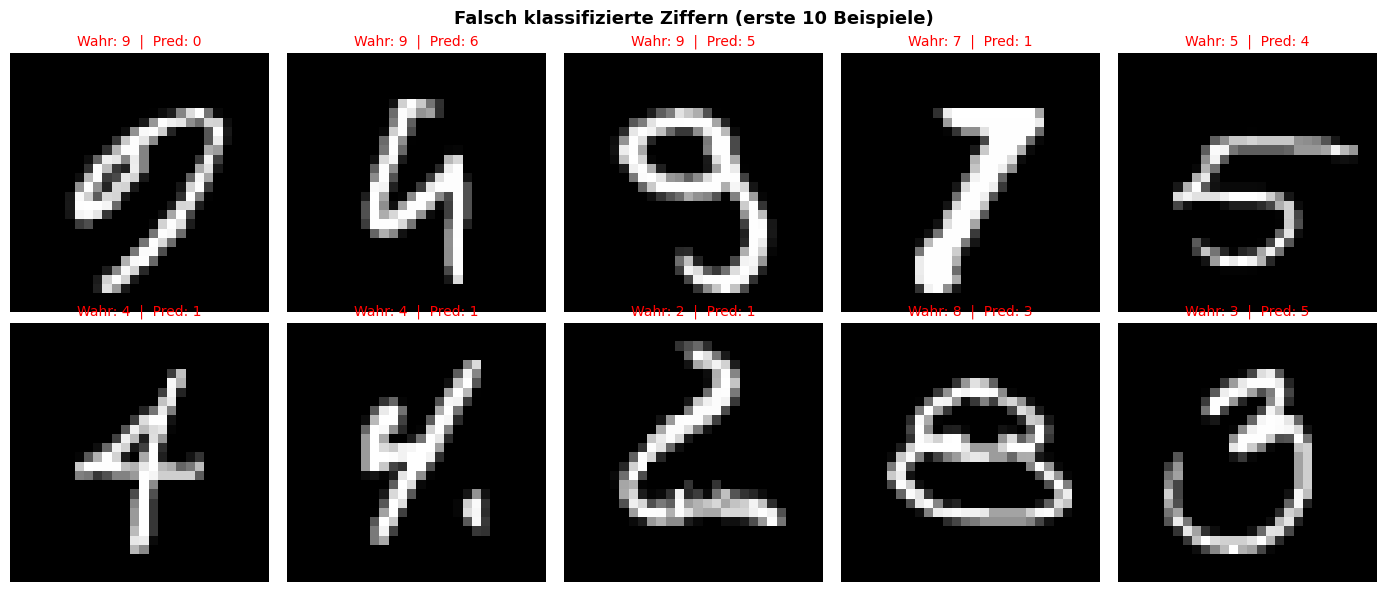

In [10]:
errors = np.where(y_pred_best != y_test)[0]

print(f'Anzahl Fehler: {len(errors)} von {len(y_test)} Testbildern')
print(f'Fehlerrate:    {len(errors)/len(y_test)*100:.2f}%')

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.ravel(), errors[:10]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(
        f'Wahr: {y_test[idx]}  |  Pred: {y_pred_best[idx]}',
        color='red', fontsize=10
    )
    ax.axis('off')

plt.suptitle('Falsch klassifizierte Ziffern (erste 10 Beispiele)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
# Haeufigste Verwechslungspaare
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

flat_idx = np.argsort(cm_offdiag.ravel())[::-1][:5]
print('Top-5 Verwechslungspaare (Wahr -> Vorhergesagt | Anzahl):')
for idx in flat_idx:
    true_label = idx // 10
    pred_label = idx % 10
    count = cm_offdiag[true_label, pred_label]
    print(f'  {true_label} -> {pred_label} : {count} Mal')


Top-5 Verwechslungspaare (Wahr -> Vorhergesagt | Anzahl):
  4 -> 9 : 7 Mal
  2 -> 7 : 6 Mal
  8 -> 5 : 5 Mal
  8 -> 1 : 5 Mal
  4 -> 1 : 5 Mal


## 11. Der Fluch der Dimensionalitaet

k-NN funktioniert hier ueberraschend gut - obwohl jedes Bild **784 Dimensionen** hat.  
Das ist kein Widerspruch, sondern ein wichtiger Lernpunkt.

### Warum funktioniert k-NN auf MNIST trotzdem?

MNIST ist ein **sehr sauberer, zentrierter Datensatz**.  
Aehnliche Ziffern liegen im 784-dimensionalen Raum tatsaechlich nah beieinander -  
auch wenn die raeumliche Struktur beim Flattening verloren geht.

### Wo liegt die praktische Grenze?

```
Datenmenge verdoppeln:
  -> Speicherbedarf verdoppelt sich
  -> Vorhersagezeit verdoppelt sich

Dimensionen erhoehen (z. B. groessere Bilder):
  -> Abstaende werden weniger aussagekraeftig
  -> Alle Punkte werden sich aehnlich 'weit' - Nachbarschaft verliert Bedeutung
```

> **Merksatz:** k-NN ist ein Lazy Learner - er lernt nichts, er merkt sich alles.  
> Das ist beim Training billig, bei der Vorhersage teuer.

**Ausblick:** In Kapitel 12 lernen wir PCA als Methode zur Dimensionsreduktion kennen.  
PCA kann k-NN auf hochdimensionalen Daten erheblich beschleunigen - bei kaum schlechterer Accuracy.


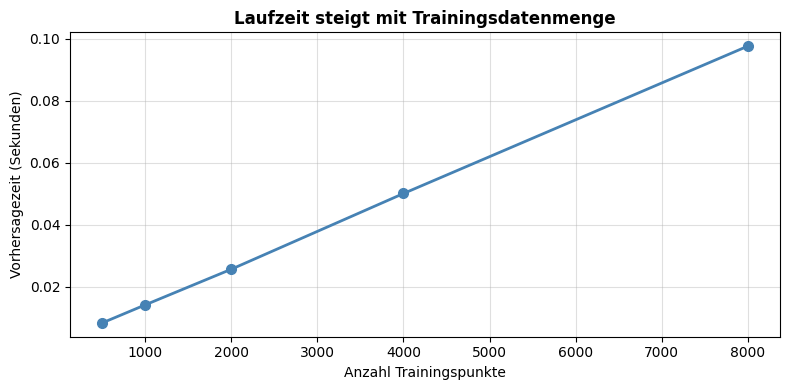

Beobachtung: Die Vorhersagezeit waechst annaehernd linear mit der Datenmenge.
Bei einem neuronalen Netz waere die Vorhersagezeit unabhaengig von der Trainingsmenge.


In [12]:
sizes  = [500, 1000, 2000, 4000, 8000]
times_ = []

knn_test = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=3))
])

for s in sizes:
    X_s, _, y_s, _ = train_test_split(X_train, y_train, train_size=s,
                                       stratify=y_train, random_state=42)
    knn_test.fit(X_s, y_s)
    t0 = time.time()
    knn_test.predict(X_test[:200])
    times_.append(time.time() - t0)

plt.figure(figsize=(8, 4))
plt.plot(sizes, times_, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.xlabel('Anzahl Trainingspunkte')
plt.ylabel('Vorhersagezeit (Sekunden)')
plt.title('Laufzeit steigt mit Trainingsdatenmenge', fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Beobachtung: Die Vorhersagezeit waechst annaehernd linear mit der Datenmenge.')
print('Bei einem neuronalen Netz waere die Vorhersagezeit unabhaengig von der Trainingsmenge.')


## 12. Groessere Projektaufgabe

1. Vergleichen Sie das Basismodell mit dem besten GridSearch-Modell.
   Diskutieren Sie: Accuracy, Laufzeit, zusaetzlicher Aufwand.

2. Erweitern Sie die Hyperparameter-Suche:
   - groessere Werte fuer `n_neighbors` (z. B. 11, 15, 21)
   - eventuell anderes Subsampling

3. Untersuchen Sie, wie sich die Laufzeit veraendert bei mehr Trainings- oder Testdaten.

4. Analysieren Sie die Konfusionsmatrix:
   - Welche Ziffern werden besonders gut erkannt?
   - Welche werden haeufiger verwechselt, und warum?

5. Schreiben Sie eine kurze Reflexion:
   - Warum funktioniert k-NN auf MNIST ueberraschend gut?
   - Warum ist das Verfahren trotzdem praktisch begrenzt?


## 13. Musterloesung

**Wichtiger Hinweis:**  
Die exakten Accuracy- und Laufzeitwerte koennen je nach Hardware und Subsampling leicht variieren.  
Fuer die Vorlesung sind die **qualitativen Zusammenhaenge** entscheidend.

### Teil 1: Basismodell vs. GridSearch

Typischerweise verbessert GridSearch das Basismodell nur **moderat** (unter 1 Prozentpunkt).  
Der zusaetzliche Rechenaufwand ist jedoch ein Vielfaches.  
**Kernaussage:** Hyperparameter-Suche ist methodisch sinnvoll, aber Zusatznutzen und Kosten abwaegen.

### Teil 2: Erweiterte Hyperparameter-Suche

Groessere Werte von `n_neighbors` koennen das Modell stabiler machen, fuehren aber nicht zwingend  
zu besseren Ergebnissen. Ein groesseres Subsampling verbessert die Accuracy etwas, erhoht aber die Laufzeit.

### Teil 3: Laufzeit und Datenmenge

Die Vorhersagezeit waechst **linear** mit der Trainingsmenge.  
k-NN hat keine klassische Trainingsphase, aber eine teure Vorhersagephase:  
Abstande zu allen Trainingspunkten muessen berechnet werden.  
**Kernaussage:** Ein einfaches Verfahren ist nicht automatisch ein billiges Verfahren.

### Teil 4: Konfusionsmatrix

Typische Verwechslungen: 3 und 5, 4 und 9, 7 und 9.  
Die Fehlerbilder zeigen: Viele Verwechslungen sind auch fuer Menschen nicht eindeutig.  
Die Konfusionsmatrix zeigt nicht nur die Gesamtguete, sondern die **Struktur der Fehler**.

### Teil 5: Reflexion

**Warum funktioniert k-NN auf MNIST gut?**  
Aehnliche Ziffern liegen im 784-dimensionalen Raum tatsaechlich nah beieinander.  
MNIST ist sauber, zentriert und gut standardisiert - das kommt k-NN zugute.

**Warum ist das Verfahren praktisch begrenzt?**  
k-NN speichert alle Daten und berechnet bei jeder Vorhersage alle Abstaende.  
Auf realen Bildmengen (Millionen Bilder, hoehere Aufloesung) ist das nicht skalierbar.

---

## 14. Zusammenfassung

- **Accuracy:** k-NN liefert auf MNIST starke Baseline-Ergebnisse
- **Pipeline:** methodisch notwendig - schuetzt vor Data Leakage
- **GridSearch:** verbessert meist moderat, kostet deutlich mehr Zeit
- **Fehlervisualisierung:** macht Verwechslungen inhaltlich erklaerbar
- **Laufzeit:** waechst linear mit Datenmenge - zentraler Nachteil von k-NN
- **Fluch der Dimensionalitaet:** MNIST ist guenstig fuer k-NN; unstrukturierte Hochdimensionsdaten sind problematischer
- **Ausblick Kapitel 12:** PCA reduziert Dimensionen und kann k-NN erheblich beschleunigen
